In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import NullFormatter
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

In [2]:
# Load Mixing Capacity data
date_one_to_one_gaussian_mc = "03060920"
with open(f"../Results_averaged/mixing_capacity_qrc_gaussian_results_{date_one_to_one_gaussian_mc}_averaged.pkl", "rb") as f:
    data_one_to_one_gaussian_mc = pickle.load(f)

date_fill_gaussian_mc = "03061219"
with open(f"../Results_averaged/mixing_capacity_qrc_gaussian_results_{date_fill_gaussian_mc}_averaged.pkl", "rb") as f:
    data_fill_gaussian_mc = pickle.load(f)

date_dense_gaussian_mc = "03061220"
with open(f"../Results_averaged/mixing_capacity_qrc_gaussian_results_{date_dense_gaussian_mc}_averaged.pkl", "rb") as f:
    data_dense_gaussian_mc = pickle.load(f)

date_one_to_one_spin_mc = "03080810"
with open(f"../Results_averaged/mixing_capacity_qrc_tilted_tfim_results_{date_one_to_one_spin_mc}_averaged.pkl", "rb") as f:
    data_one_to_one_spin_mc = pickle.load(f)

date_fill_spin_mc = "03080816"
with open(f"../Results_averaged/mixing_capacity_qrc_tilted_tfim_results_{date_fill_spin_mc}_averaged.pkl", "rb") as f:
    data_fill_spin_mc = pickle.load(f)

date_dense_spin_mc = "03080818"
with open(f"../Results_averaged/mixing_capacity_qrc_tilted_tfim_results_{date_dense_spin_mc}_averaged.pkl", "rb") as f:
    data_dense_spin_mc = pickle.load(f)

df_mc_oto_g = pd.DataFrame(data_one_to_one_gaussian_mc)
df_mc_fill_g = pd.DataFrame(data_fill_gaussian_mc)
df_mc_dense_g = pd.DataFrame(data_dense_gaussian_mc)
df_mc_oto_s = pd.DataFrame(data_one_to_one_spin_mc)
df_mc_fill_s = pd.DataFrame(data_fill_spin_mc)
df_mc_dense_s = pd.DataFrame(data_dense_spin_mc)

In [3]:
# Load Lorenz63 data
date_one_to_one_gaussian_l = "03081457"
with open(f"../Results_averaged/lorenz63_qrc_gaussian_results_{date_one_to_one_gaussian_l}_averaged.pkl", "rb") as f:
    data_one_to_one_gaussian_l = pickle.load(f)

date_fill_gaussian_l = "03111048"
with open(f"../Results_averaged/lorenz63_qrc_gaussian_results_{date_fill_gaussian_l}_averaged.pkl", "rb") as f:
    data_fill_gaussian_l = pickle.load(f)

date_dense_gaussian_l = "03081501"
with open(f"../Results_averaged/lorenz63_qrc_gaussian_results_{date_dense_gaussian_l}_averaged.pkl", "rb") as f:
    data_dense_gaussian_l = pickle.load(f)

date_one_to_one_spin_l = "03160921"
with open(f"../Results_averaged/lorenz63_qrc_tilted_tfim_results_{date_one_to_one_spin_l}_averaged.pkl", "rb") as f:
    data_one_to_one_spin_l = pickle.load(f)

date_fill_spin_l = "03161007"
with open(f"../Results_averaged/lorenz63_qrc_tilted_tfim_results_{date_fill_spin_l}_averaged.pkl", "rb") as f:
    data_fill_spin_l = pickle.load(f)

date_dense_spin_l = "03161009"
with open(f"../Results_averaged/lorenz63_qrc_tilted_tfim_results_{date_dense_spin_l}_averaged.pkl", "rb") as f:
    data_dense_spin_l = pickle.load(f)

df_l_oto_g = pd.DataFrame(data_one_to_one_gaussian_l)
df_l_fill_g = pd.DataFrame(data_fill_gaussian_l)
df_l_dense_g = pd.DataFrame(data_dense_gaussian_l)
df_l_oto_s = pd.DataFrame(data_one_to_one_spin_l)
df_l_fill_s = pd.DataFrame(data_fill_spin_l)
df_l_dense_s = pd.DataFrame(data_dense_spin_l)

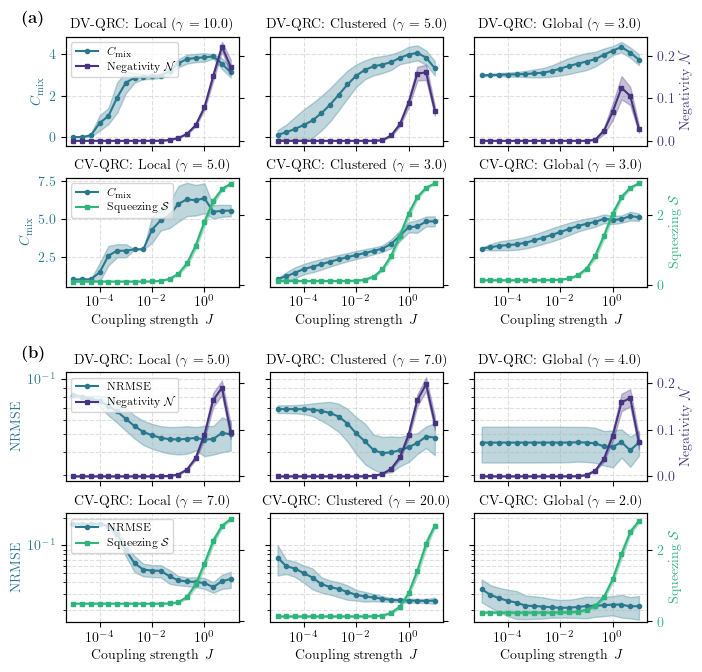

In [4]:
# ── Data structures ──
models_data_mc = [
    ("DV-QRC", [
        ("Local", df_mc_oto_s),
        ("Clustered", df_mc_fill_s),
        ("Global", df_mc_dense_s)
    ]),
    ("CV-QRC", [
        ("Local", df_mc_oto_g),
        ("Clustered", df_mc_fill_g),
        ("Global", df_mc_dense_g)
    ])
]

models_data_l = [
    ("DV-QRC", [
        ("Local", df_l_oto_s),
        ("Clustered", df_l_fill_s),
        ("Global", df_l_dense_s)
    ]),
    ("CV-QRC", [
        ("Local", df_l_oto_g),
        ("Clustered", df_l_fill_g),
        ("Global", df_l_dense_g)
    ])
]

# ── Colors ──
viridis_cmap = plt.get_cmap("viridis")
prim_color = viridis_cmap(0.4)
neg_color = viridis_cmap(0.15)
sqz_color = viridis_cmap(0.65)

# ── 5-row grid: rows 0-1 = panel (a), row 2 = spacer, rows 3-4 = panel (b) ──
fig = plt.figure(figsize=(7.5, 7.6))
gs = gridspec.GridSpec(
    5, 3, figure=fig,
    height_ratios=[1, 1, 0.2, 1, 1],  # adjust 0.3 to control gap between (a) and (b)
    hspace=0.35,   # spacing between rows within each panel — decrease to bring closer
    wspace=0.18,
)

# Create all 12 axes, skipping gridspec row 2 (the spacer)
axes = np.empty((4, 3), dtype=object)
for row in range(4):
    gs_row = row if row < 2 else row + 1  # skip gridspec row 2
    for col in range(3):
        axes[row, col] = fig.add_subplot(gs[gs_row, col])

# ── Manual x-axis sharing: all 12 subplots share x ──
for row in range(4):
    for col in range(3):
        if not (row == 0 and col == 0):
            axes[row, col].sharex(axes[0, 0])

# ── Manual y-axis sharing per row-pair ──
# Rows 0-1 (mixing capacity) share primary y within each row
for col in range(1, 3):
    axes[0, col].sharey(axes[0, 0])
    axes[1, col].sharey(axes[1, 0])
# Rows 2-3 (Lorenz) share primary y within each row
for col in range(1, 3):
    axes[2, col].sharey(axes[2, 0])
    axes[3, col].sharey(axes[3, 0])

# =====================================================================
# (a) Mixing Capacity – rows 0 & 1
# =====================================================================
target_encoding_mc = 0.1
mix_mean_col = "first_moment_2_mean"
mix_std_col = "first_moment_2_std"

row_axes_data_mc = []

for i, (row_label, cols) in enumerate(models_data_mc):
    if "DV" in row_label:
        sec_mean_col = "negativity_mean"
        sec_std_col = "negativity_std"
        sec_ylabel = r"Negativity $\mathcal{N}$"
        sec_color = neg_color
        mix_multiplier = 18.0
    else:
        sec_mean_col = "squeezing_mean"
        sec_std_col = "squeezing_std"
        sec_ylabel = r"Squeezing $\mathcal{S}$"
        sec_color = sqz_color
        mix_multiplier = 21.0

    row_y1_min, row_y1_max = float('inf'), float('-inf')
    row_y2_min, row_y2_max = float('inf'), float('-inf')
    row_ax2s = []

    for j, (col_label, df) in enumerate(cols):
        ax = axes[i, j]  # rows 0 and 1

        gamma_str = ""
        if "gamma" in df.columns:
            ug = df["gamma"].dropna().unique()
            if len(ug) > 0:
                gamma_str = r" ($\gamma=" + str(ug[0]) + r"$)"
        ax.set_title(f"{row_label}: {col_label}{gamma_str}", fontsize=10)

        mask = (df["encoding_strength"].notna()) & (abs(df["encoding_strength"] - target_encoding_mc) < 1e-5)
        sub_df = df[mask].copy()

        ax2 = ax.twinx()
        row_ax2s.append(ax2)

        if sub_df.empty:
            ax.text(0.5, 0.5, f"No data for\n$\\epsilon={target_encoding_mc}$",
                    ha="center", va="center", transform=ax.transAxes, alpha=0.6)
        else:
            sub_df = sub_df.sort_values(by="coupling_strength")
            x = sub_df["coupling_strength"].values

            if mix_mean_col in sub_df.columns:
                y1_mean = sub_df[mix_mean_col].values * mix_multiplier
                y1_std = sub_df[mix_std_col].values * mix_multiplier if mix_std_col in sub_df.columns else np.zeros_like(y1_mean)
                ax.plot(x, y1_mean, color=prim_color, label=r"$C_\mathrm{mix}$", marker="o", markersize=3)
                ax.fill_between(x, y1_mean - y1_std, y1_mean + y1_std, color=prim_color, alpha=0.3)
                row_y1_min = min(row_y1_min, (y1_mean - y1_std).min())
                row_y1_max = max(row_y1_max, (y1_mean + y1_std).max())

            ax.set_xscale("log")
            ax.grid(True, which="both", ls="--", alpha=0.4)
            ax.tick_params(axis='y', labelcolor=prim_color)

            if sec_mean_col in sub_df.columns:
                y2_mean = sub_df[sec_mean_col].values
                y2_std = sub_df[sec_std_col].values if sec_std_col in sub_df.columns else np.zeros_like(y2_mean)
                ax2.plot(x, y2_mean, color=sec_color, label=f"{sec_ylabel}", marker="s", markersize=3)
                lower_bound_y2 = y2_mean - y2_std
                ax2.fill_between(x, lower_bound_y2, y2_mean + y2_std, color=sec_color, alpha=0.3)
                row_y2_min = min(row_y2_min, lower_bound_y2.min())
                row_y2_max = max(row_y2_max, (y2_mean + y2_std).max())

            ax2.tick_params(axis='y', labelcolor=sec_color)

            if j == 0:
                lines_1, labels_1 = ax.get_legend_handles_labels()
                lines_2, labels_2 = ax2.get_legend_handles_labels()
                if lines_1 or lines_2:
                    ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left", fontsize=8)

        if i == 1:
            ax.set_xlabel(r"Coupling strength $J$")
        if j == 0:
            ax.set_ylabel(r"$C_\mathrm{mix}$", color=prim_color)
        if j == 2:
            ax2.set_ylabel(sec_ylabel, color=sec_color)
        else:
            ax2.set_yticklabels([])

    row_axes_data_mc.append({
        'row_idx': i, 'ax2s': row_ax2s,
        'y1_min': row_y1_min, 'y1_max': row_y1_max,
        'y2_min': row_y2_min, 'y2_max': row_y2_max
    })

for row_data in row_axes_data_mc:
    i = row_data['row_idx']
    r1_min, r1_max = row_data['y1_min'], row_data['y1_max']
    if r1_min != float('inf'):
        y1_pad = (r1_max - r1_min) * 0.05
        if y1_pad == 0: y1_pad = 0.1
        for ax in axes[i, :]:
            ax.set_ylim(r1_min - y1_pad, r1_max + y1_pad)
    r2_min, r2_max = row_data['y2_min'], row_data['y2_max']
    if r2_min != float('inf'):
        y2_pad = (r2_max - r2_min) * 0.05
        if y2_pad == 0: y2_pad = 0.1
        for ax2 in row_data['ax2s']:
            ax2.set_ylim(r2_min - y2_pad, r2_max + y2_pad)

# =====================================================================
# (b) Lorenz63 NRMSE – rows 2 & 3
# =====================================================================
target_encoding_l = 1.0
nrmse_mean_col = "first_moment_nrmse_test_average_mean"
nrmse_std_col = "first_moment_nrmse_test_average_std"

row_axes_data_l = []

for i, (row_label, cols) in enumerate(models_data_l):
    grid_row = i + 2  # axes rows 2 & 3 (mapped to gridspec rows 3 & 4)

    if "DV" in row_label:
        sec_mean_col = "negativity_mean"
        sec_std_col = "negativity_std"
        sec_ylabel = r"Negativity $\mathcal{N}$"
        sec_color = neg_color
    else:
        sec_mean_col = "squeezing_mean"
        sec_std_col = "squeezing_std"
        sec_ylabel = r"Squeezing $\mathcal{S}$"
        sec_color = sqz_color

    row_y1_min, row_y1_max = float('inf'), float('-inf')
    row_y2_min, row_y2_max = float('inf'), float('-inf')
    row_ax2s = []

    for j, (col_label, df_original) in enumerate(cols):
        ax = axes[grid_row, j]
        ax2 = ax.twinx()
        row_ax2s.append(ax2)

        if grid_row == 3:
            ax.set_xlabel(r"Coupling strength $J$")
        if j == 0:
            ax.set_ylabel("NRMSE", color=prim_color)
        if j == 2:
            ax2.set_ylabel(sec_ylabel, color=sec_color)
        else:
            ax2.set_yticklabels([])

        df = df_original.copy()
        gamma_str = ""
        has_data = False

        if not df.empty:
            if "gamma" in df.columns:
                ug = df["gamma"].dropna().unique()
                if len(ug) > 0:
                    gamma_str = r" ($\gamma=" + str(ug[0]) + r"$)"
            if 'd' in df.columns:
                df = df[df['d'] == 3]
            if nrmse_mean_col in df.columns:
                df['nrmse_val'] = df[nrmse_mean_col].apply(lambda x: x[0] if isinstance(x, (np.ndarray, list)) else x)
            if nrmse_std_col in df.columns:
                df['nrmse_err'] = df[nrmse_std_col].apply(lambda x: x[0] if isinstance(x, (np.ndarray, list)) else x)
            if "encoding_strength" in df.columns:
                mask = (df["encoding_strength"].notna()) & (abs(df["encoding_strength"] - target_encoding_l) < 1e-5)
                sub_df = df[mask].copy()
                if not sub_df.empty and 'nrmse_val' in sub_df.columns and not sub_df['nrmse_val'].dropna().empty:
                    has_data = True

        ax.set_title(f"{row_label}: {col_label}{gamma_str}", fontsize=10)

        if not has_data:
            ax.text(0.5, 0.5, f"No data for\n$\\epsilon={target_encoding_l}$",
                    ha="center", va="center", transform=ax.transAxes, alpha=0.6)
        else:
            sub_df = sub_df.sort_values(by="coupling_strength")
            x = sub_df["coupling_strength"].values

            y1_mean = sub_df['nrmse_val'].values
            y1_std = sub_df['nrmse_err'].values if 'nrmse_err' in sub_df.columns else np.zeros_like(y1_mean)
            ax.plot(x, y1_mean, color=prim_color, label="NRMSE", marker="o", markersize=3)
            lower_bound_y1 = np.clip(y1_mean - y1_std, a_min=1e-8, a_max=None)
            ax.fill_between(x, lower_bound_y1, y1_mean + y1_std, color=prim_color, alpha=0.3)
            row_y1_min = min(row_y1_min, y1_mean.min())
            row_y1_max = max(row_y1_max, (y1_mean + y1_std).max())

            ax.set_xscale("log")
            ax.set_yscale("log")
            ax.grid(True, which="both", ls="--", alpha=0.4)
            ax.tick_params(axis='y', labelcolor=prim_color)
            ax.yaxis.set_minor_formatter(NullFormatter())

            if sec_mean_col in sub_df.columns:
                y2_mean = sub_df[sec_mean_col].values
                y2_std = sub_df[sec_std_col].values if sec_std_col in sub_df.columns else np.zeros_like(y2_mean)
                ax2.plot(x, y2_mean, color=sec_color, label=f"{sec_ylabel}", marker="s", markersize=3)
                lower_bound_y2 = y2_mean - y2_std
                ax2.fill_between(x, lower_bound_y2, y2_mean + y2_std, color=sec_color, alpha=0.3)
                row_y2_min = min(row_y2_min, lower_bound_y2.min())
                row_y2_max = max(row_y2_max, (y2_mean + y2_std).max())

            ax2.tick_params(axis='y', labelcolor=sec_color)

            if j == 0:
                lines_1, labels_1 = ax.get_legend_handles_labels()
                lines_2, labels_2 = ax2.get_legend_handles_labels()
                if lines_1 or lines_2:
                    ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left", fontsize=8)

    row_axes_data_l.append({
        'grid_row': grid_row, 'ax2s': row_ax2s,
        'y1_min': row_y1_min, 'y1_max': row_y1_max,
        'y2_min': row_y2_min, 'y2_max': row_y2_max
    })

for row_data in row_axes_data_l:
    gr = row_data['grid_row']
    r1_min, r1_max = row_data['y1_min'], row_data['y1_max']
    if r1_min != float('inf'):
        pad1_min = r1_min * 0.7
        pad1_max = r1_max * 1.3
        for ax in axes[gr, :]:
            if ax.get_yscale() == 'log':
                ax.set_ylim(pad1_min, pad1_max)
    r2_min, r2_max = row_data['y2_min'], row_data['y2_max']
    if r2_min != float('inf'):
        y2_pad = (r2_max - r2_min) * 0.05
        if y2_pad == 0: y2_pad = 0.1
        for ax2 in row_data['ax2s']:
            ax2.set_ylim(r2_min - y2_pad, r2_max + y2_pad)

# ── Hide tick labels AFTER all plotting is done ──
# Hide x-tick labels on non-bottom rows of each panel
for row in [0, 2]:
    for col in range(3):
        axes[row, col].tick_params(axis='x', labelbottom=False)

# Hide primary y-tick labels on columns 1 and 2 (only show on leftmost column)
for row in range(4):
    for col in range(1, 3):
        axes[row, col].tick_params(axis='y', labelleft=False)

# ── Panel labels (a) and (b) ──
axes[0, 0].text(-0.25, 1.25, r"\textbf{(a)}", fontsize=12, transform=axes[0, 0].transAxes, va="top", ha="left")
axes[2, 0].text(-0.25, 1.25, r"\textbf{(b)}", fontsize=12, transform=axes[2, 0].transAxes, va="top", ha="left")

plt.savefig("../Plots/combined_1d_mixing_lorenz.pdf", bbox_inches='tight')
plt.show()